In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [56]:
df_filtered["Year"].unique()


array([2011, 2015, 2021, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2012, 2013, 2014, 2016, 2017, 2018, 2019, 2020,
       2022, 2023, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2024])

In [57]:
df_filtered.groupby("World regions according to OWID")["Year"].nunique()


World regions according to OWID
Africa           1
Asia             1
Europe           1
North America    1
Oceania          1
South America    1
Name: Year, dtype: int64

In [58]:
# URL zur Our-World-in-Data CSV (Alphabetisierung vs. BIP pro Kopf)
url = "https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita.csv"

# CSV von der URL einlesen
df = pd.read_csv(url)

# ersten Eindruck bekommen
df.head()


,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


In [59]:
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59712 entries, 0 to 59711
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               59712 non-null  object 
 1   Code                                                 55519 non-null  object 
 2   Year                                                 59712 non-null  int64  
 3   Literacy rate among adults                           1725 non-null   float64
 4   GDP per capita, PPP (constant 2021 international $)  7236 non-null   float64
 5   Population (historical)                              58824 non-null  float64
 6   World regions according to OWID                      272 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 3.2+ MB


Index(['Entity', 'Code', 'Year', 'Literacy rate among adults',
       'GDP per capita, PPP (constant 2021 international $)',
       'Population (historical)', 'World regions according to OWID'],
      dtype='object')

In [60]:
df.columns


Index(['Entity', 'Code', 'Year', 'Literacy rate among adults',
       'GDP per capita, PPP (constant 2021 international $)',
       'Population (historical)', 'World regions according to OWID'],
      dtype='object')

In [61]:
df_filtered = df[(df["Year"] >= 1985) & (df["Year"] <= 2025)]
df_filtered.head()



,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN
5,Afghanistan,AFG,2001,NaN,1454.1108,20284303.0,NaN


In [62]:
df_filtered.isna().sum()


Entity                                                     0
Code                                                    1294
Year                                                       0
Literacy rate among adults                              9397
GDP per capita, PPP (constant 2021 international $)     3681
Population (historical)                                  797
World regions according to OWID                        10645
dtype: int64

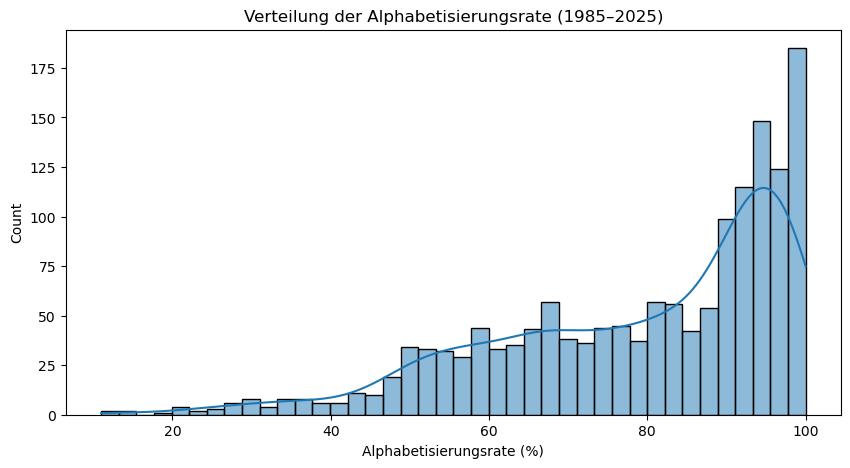

In [63]:
plt.figure(figsize=(10,5))
sns.histplot(df_filtered["Literacy rate among adults"], bins=40, kde=True)
plt.xlabel("Alphabetisierungsrate (%)")
plt.title("Verteilung der Alphabetisierungsrate (1985–2025)")
plt.show()


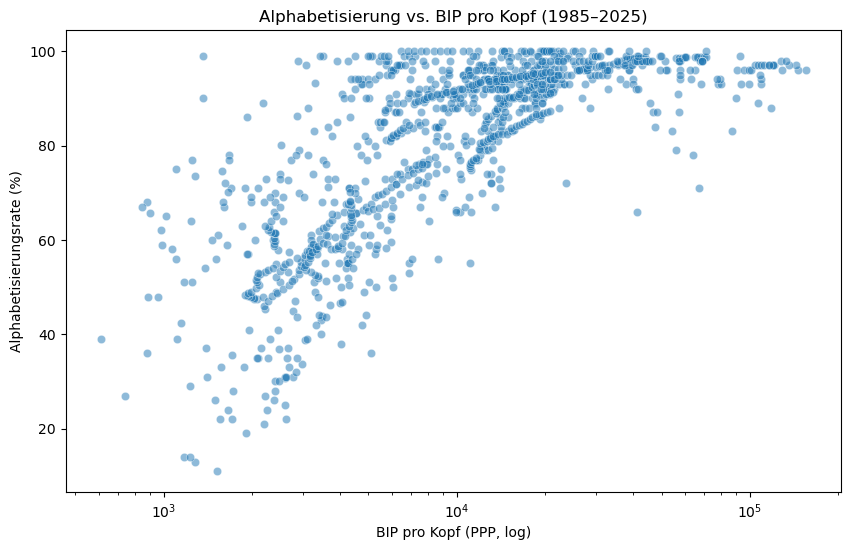

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_filtered,
    x="GDP per capita, PPP (constant 2021 international $)",
    y="Literacy rate among adults",
    alpha=0.5
)
plt.xscale("log")
plt.xlabel("BIP pro Kopf (PPP, log)")
plt.ylabel("Alphabetisierungsrate (%)")
plt.title("Alphabetisierung vs. BIP pro Kopf (1985–2025)")
plt.show()


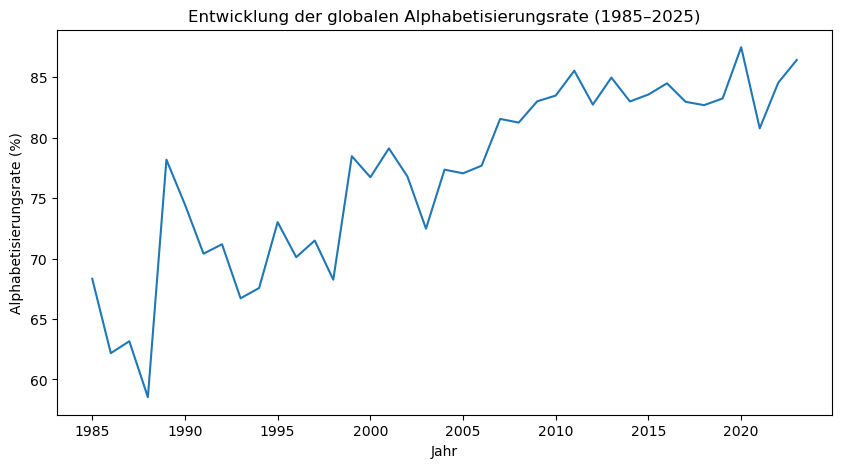

In [65]:
df_yearly = df_filtered.groupby("Year").mean(numeric_only=True).reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_yearly, x="Year", y="Literacy rate among adults")
plt.xlabel("Jahr")
plt.ylabel("Alphabetisierungsrate (%)")
plt.title("Entwicklung der globalen Alphabetisierungsrate (1985–2025)")
plt.show()


In [66]:
df_filtered[["Literacy rate among adults", 
             "GDP per capita, PPP (constant 2021 international $)"]].corr()



,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)"
Literacy rate among adults,1.000000,0.439927
"GDP per capita, PPP (constant 2021 international $)",0.439927,1.000000


C:\Users\lilia\AppData\Local\Temp\ipykernel_26916\3527206203.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


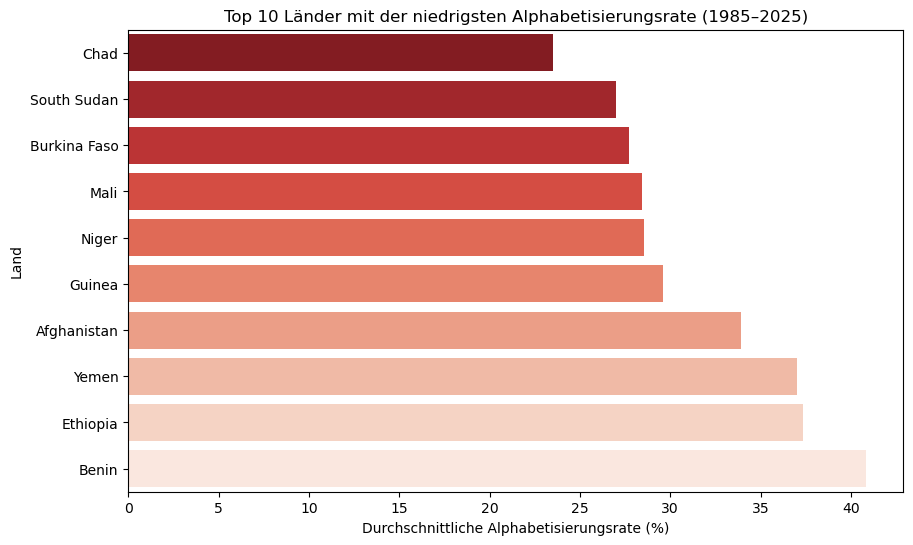

In [67]:
# Mittelwert pro Land berechnen
df_country_mean = df_filtered.groupby("Entity")["Literacy rate among adults"].mean().reset_index()

# zum sortieren der 10 niedrigsten Ländern
df_lowest10 = df_country_mean.sort_values("Literacy rate among adults").head(10)

# Balkendiagramm plotten
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_lowest10,
    x="Literacy rate among adults",
    y="Entity",
    palette="Reds_r"
)
plt.xlabel("Durchschnittliche Alphabetisierungsrate (%)")
plt.ylabel("Land")
plt.title("Top 10 Länder mit der niedrigsten Alphabetisierungsrate (1985–2025)")
plt.show()


In [68]:
url_lit = "https://ourworldindata.org/grapher/literacy-rate.csv"
df_lit = pd.read_csv(url_lit)

df_lit.head()
df_lit.columns



Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)'],
      dtype='object')

In [69]:
# Wir haben den Ländern den entsprechenden Regionen hinzugefügt, indem eine weitere Spalte hinzugefühgt wurde
df_lit_region = df_lit.merge(
    df_regions,
    on="Entity",
    how="left"
)
# Entfernung von Regionen ohne Ländern, Data Frame enthält jetzt Jahr, Land, Alphabetisierungsrage und Kontinente
df_lit_region = df_lit_region.dropna(subset=["World regions according to OWID"])
# zeigt die ersten Spalten meiner Daten, zur Kontrolle
df_lit_region.head()

,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)",World regions according to OWID
1,Afghanistan,AFG,1979,18.00000,Asia
3,Afghanistan,AFG,2011,31.00000,Asia
5,Afghanistan,AFG,2015,33.75384,Asia
7,Afghanistan,AFG,2021,37.00000,Asia
9,Albania,ALB,2001,99.00000,Europe


In [70]:
# Dieser Code verbindet unsere Alphabetisierungsdaten mit den Regionen in der Liste
# Entfernt Länder, die zu keiner Region zugewiesen wurden

df_lit_region = df_lit.merge(
    df_regions,
    on="Entity",
    how="left"
)

df_lit_region = df_lit_region.dropna(subset=["World regions according to OWID"])
df_lit_region.head()


,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)",World regions according to OWID
1,Afghanistan,AFG,1979,18.00000,Asia
3,Afghanistan,AFG,2011,31.00000,Asia
5,Afghanistan,AFG,2015,33.75384,Asia
7,Afghanistan,AFG,2021,37.00000,Asia
9,Albania,ALB,2001,99.00000,Europe


In [71]:
# Code zur Zeilenfilterung, damit nur die JAhre 1985 - 2023 vorhanden sind
df_lit_region = df_lit_region[
    (df_lit_region["Year"] >= 1985) & (df_lit_region["Year"] <= 2025)
]


In [72]:
# Zum Anzeigen aller Spalten, die in unserer Data vorhanden ist
df_lit_region.columns


Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)',
       'World regions according to OWID'],
      dtype='object')

In [73]:
# Variable hinzufügen, für spätere Berechnungen
value_col = "Literacy rate"  


In [74]:
# Spalte mit "literacy" im Namen automatisch finden
lit_cols = [c for c in df_lit_region.columns if "literacy" in c.lower()]
print("Gefundene Literacy-Spalten:", lit_cols)

# erste gefundene Spalte verwenden
lit_col = lit_cols[0]

# Zum berechnen des Mittelwerter pro Region über die Jahre hinweg
df_region_year = (
    df_lit_region
    .groupby(["World regions according to OWID", "Year"])[lit_col]
    .mean()
    .reset_index()
)

df_region_year.head()



Gefundene Literacy-Spalten: ['Literacy rate, adult total (% of people ages 15 and above)']


,World regions according to OWID,Year,"Literacy rate, adult total (% of people ages 15 and above)"
0,Africa,1986,55.500000
1,Africa,1987,61.000000
2,Africa,1988,38.500000
3,Africa,1990,61.250000
4,Africa,1991,57.285714


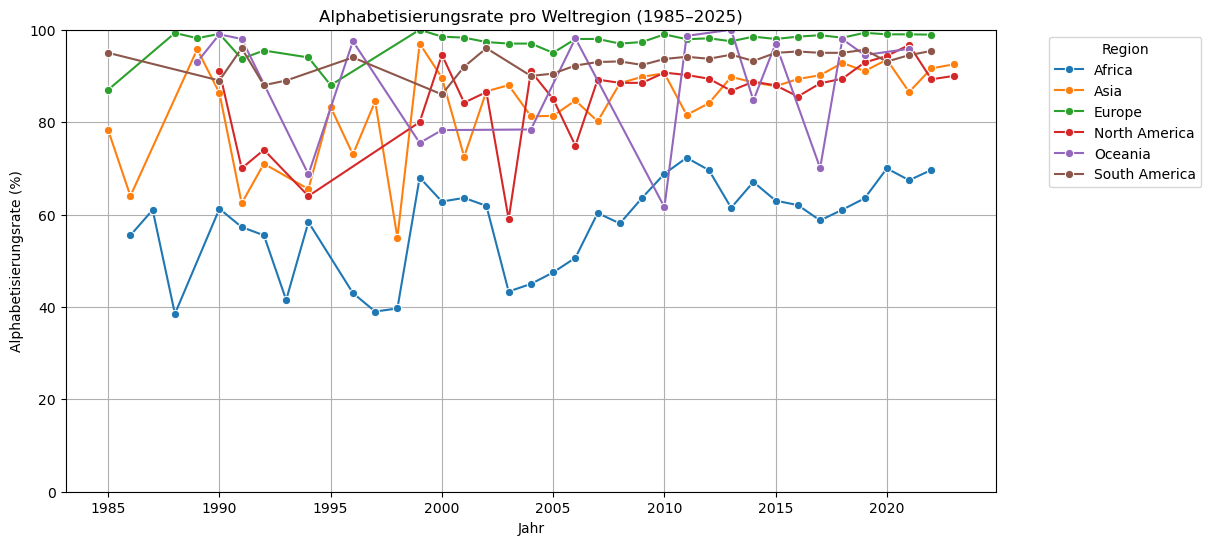

In [75]:
# Dieser Graf zeigt den Verlauf der Analphabetisierung aller Kontinente über alle Datenpunkte (1980 - 2025)
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_region_year,
    x="Year",
    y=lit_col,
    hue="World regions according to OWID",
    marker="o"
)

plt.xlabel("Jahr")
plt.ylabel("Alphabetisierungsrate (%)")
plt.title("Alphabetisierungsrate pro Weltregion (1985–2025)")
plt.ylim(0, 100)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()


In [76]:
df_ch = df_lit_region[df_lit_region["Entity"] == "Switzerland"]

df_ch


,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)",World regions according to OWID


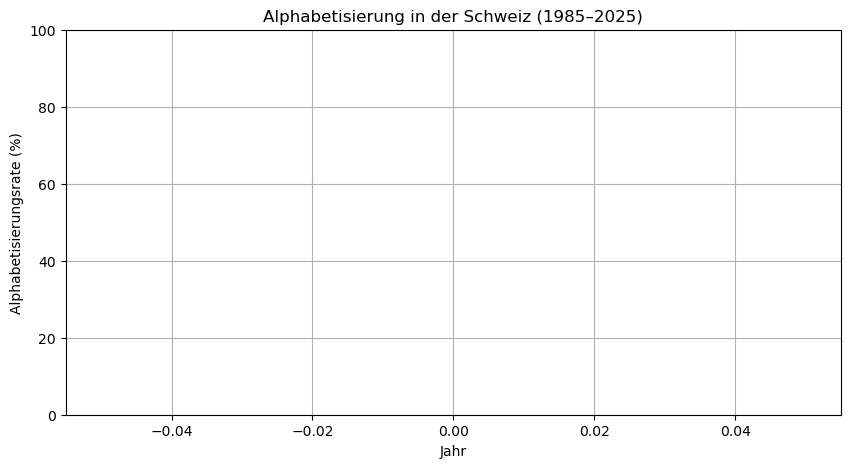

In [77]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_ch,
    x="Year",
    y=lit_col,     # <— automatisch erkannte Literacy-Spalte
    marker="o"
)
plt.xlabel("Jahr")
plt.ylabel("Alphabetisierungsrate (%)")
plt.title("Alphabetisierung in der Schweiz (1985–2025)")
plt.ylim(0, 100)
plt.grid(True)
plt.show()


In [78]:
df_filtered[df_filtered["Entity"] == "Switzerland"]


,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
51381,Switzerland,CHE,1990,NaN,64010.758,6713168.0,NaN
51382,Switzerland,CHE,1991,NaN,62636.773,6796942.0,NaN
51383,Switzerland,CHE,1992,NaN,61922.890,6875049.0,NaN
51384,Switzerland,CHE,1993,NaN,61284.203,6938106.0,NaN
51385,Switzerland,CHE,1994,NaN,61569.598,6993594.0,NaN
51386,Switzerland,CHE,1995,NaN,61453.630,7040481.0,NaN
51387,Switzerland,CHE,1996,NaN,61471.168,7071885.0,NaN
51388,Switzerland,CHE,1997,NaN,62709.990,7089161.0,NaN
51389,Switzerland,CHE,1998,NaN,64418.387,7110294.0,NaN
51390,Switzerland,CHE,1999,NaN,65177.883,7144119.0,NaN


In [79]:
df_lit_region[df_lit_region["Entity"] == "Switzerland"]
# ICh wollte eine Analphabetisierungsgraph nur aus der Schweiz machen, doch in OurWorldData sind gar keine Daten hinterlegt
# Dies heisst wahrscheinlich,  dass sie sehr hoch ist und wahrscheinlich bei 100% liegt und sehr konstant ist


,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)",World regions according to OWID


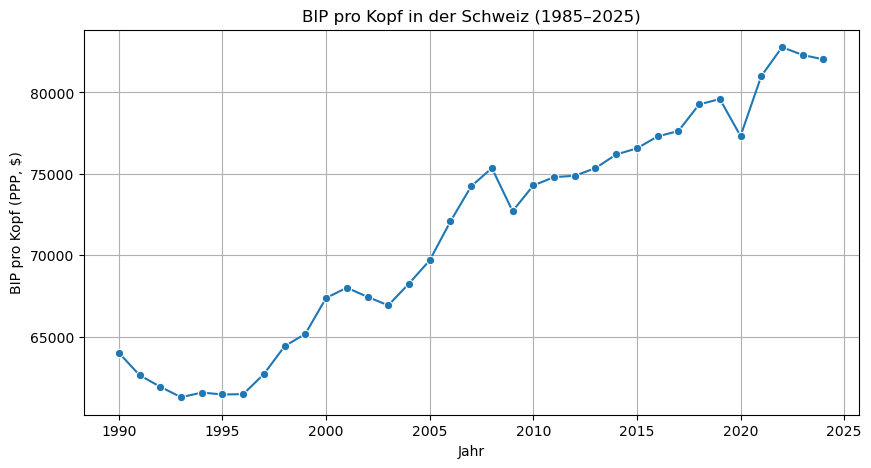

In [80]:
#BIP Verlauf der Schweiz, da keine Analphabetisierungsrate vorhanden ist
df_ch_gdp = df_filtered[df_filtered["Entity"] == "Switzerland"]

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_ch_gdp,
    x="Year",
    y="GDP per capita, PPP (constant 2021 international $)",
    marker="o"
)
plt.xlabel("Jahr")
plt.ylabel("BIP pro Kopf (PPP, $)")
plt.title("BIP pro Kopf in der Schweiz (1985–2025)")
plt.grid(True)
plt.show()


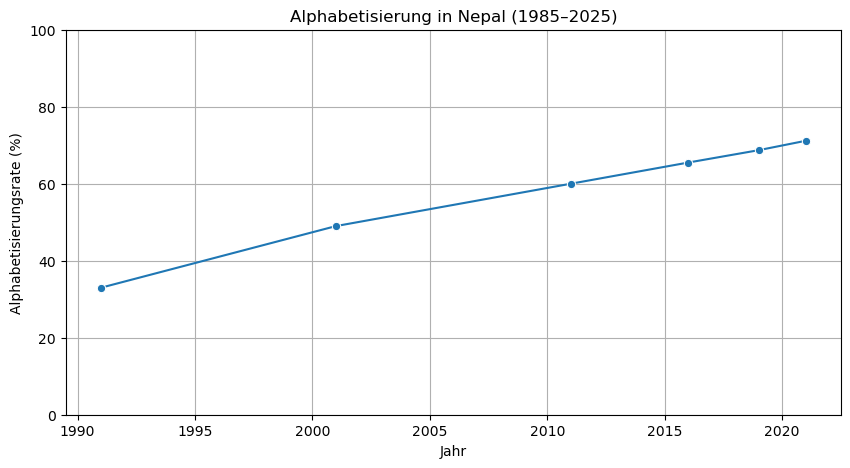

In [81]:
# Jetzt einfach ein random Land mit einer interessanten Kurve
df_ng = df_lit_region[df_lit_region["Entity"] == "Nepal"]

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_ng,
    x="Year",
    y=lit_col,   # die automatisch erkannte Literacy-Spalte
    marker="o"
)

plt.xlabel("Jahr")
plt.ylabel("Alphabetisierungsrate (%)")
plt.title("Alphabetisierung in Nepal (1985–2025)")
plt.ylim(0, 100)
plt.grid(True)
plt.show()


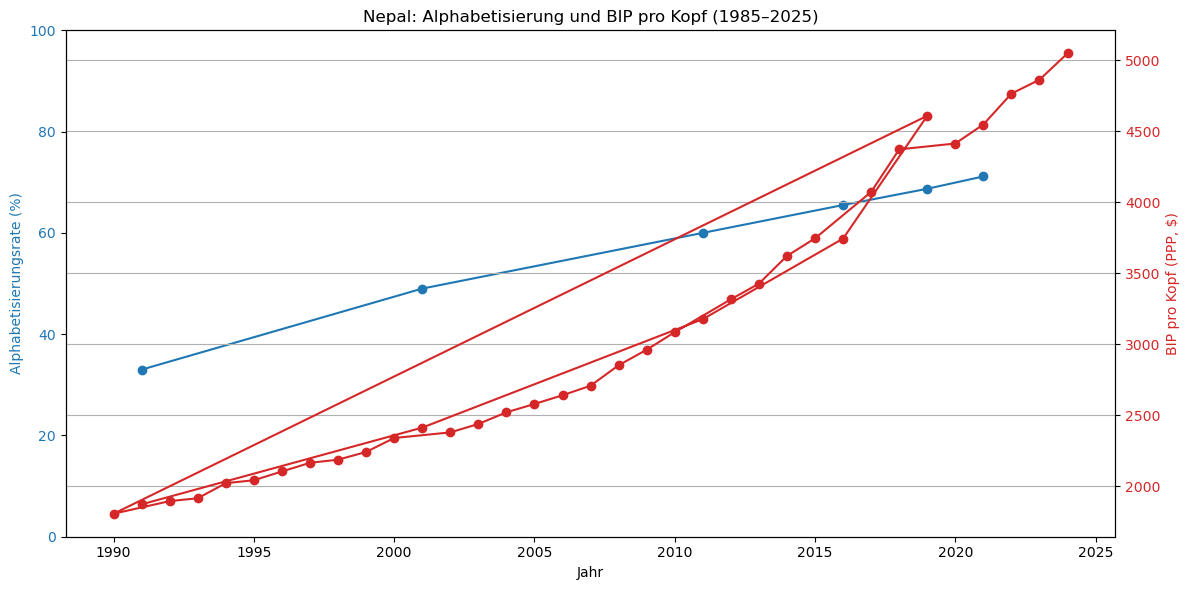

In [82]:
# Nepal aus dem BIP-Datensatz (df_filtered)
df_np_gdp = df_filtered[df_filtered["Entity"] == "Nepal"]

# Nepal aus dem Alphabetisierungs-Datensatz (df_lit_region)
df_np_lit = df_lit_region[df_lit_region["Entity"] == "Nepal"]

# Plot
fig, ax1 = plt.subplots(figsize=(12,6))

# Erste Achse: Alphabetisierung
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Alphabetisierungsrate (%)", color="tab:blue")
ax1.plot(df_np_lit["Year"], df_np_lit[lit_col], marker="o", color="tab:blue", label="Alphabetisierung")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 100)

# Zweite Achse: BIP pro Kopf
ax2 = ax1.twinx()
ax2.set_ylabel("BIP pro Kopf (PPP, $)", color="tab:red")
ax2.plot(df_np_gdp["Year"], df_np_gdp["GDP per capita, PPP (constant 2021 international $)"], marker="o", color="tab:red", label="BIP pro Kopf")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Nepal: Alphabetisierung und BIP pro Kopf (1985–2025)")
fig.tight_layout()
plt.grid(True)




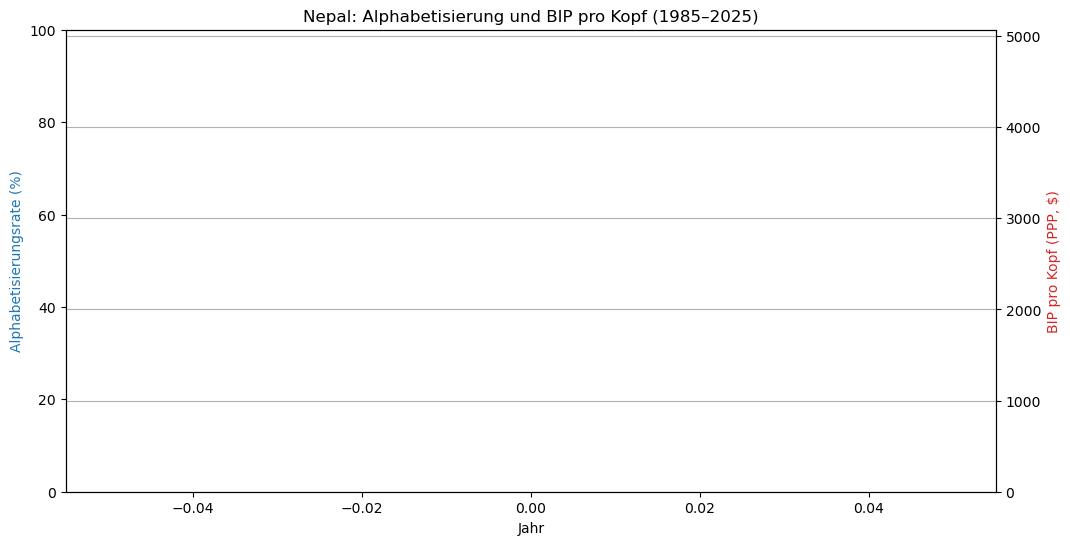

In [83]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Gemeinsame Jahre bestimmen
years = sorted(set(df_np_lit["Year"]) & set(df_np_gdp["Year"]))

# Daten über Jahre matchen
lit_values = [df_np_lit[df_np_lit["Year"] == y][lit_col].values[0] for y in years]
gdp_values = [df_np_gdp[df_np_gdp["Year"] == y]["GDP per capita, PPP (constant 2021 international $)"].values[0] for y in years]

fig, ax1 = plt.subplots(figsize=(12,6))

# Achse 1 – Alphabetisierung
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Alphabetisierungsrate (%)", color="tab:blue")
ax1.set_ylim(0, 100)
line1, = ax1.plot([], [], color="tab:blue", marker="o", label="Alphabetisierung")

# Achse 2 – BIP
ax2 = ax1.twinx()
ax2.set_ylabel("BIP pro Kopf (PPP, $)", color="tab:red")
ax2.set_ylim(0, max(gdp_values)*1.1)
line2, = ax2.plot([], [], color="tab:red", marker="o", label="BIP pro Kopf")

plt.title("Nepal: Alphabetisierung und BIP pro Kopf (1985–2025)")
plt.grid(True)

# Animationsfunktion
def animate(i):
    line1.set_data(years[:i], lit_values[:i])
    line2.set_data(years[:i], gdp_values[:i])
    return line1, line2

ani = FuncAnimation(fig, animate, frames=len(years), interval=300, blit=True)

plt.show()
